In [1]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 97.3 MB/s eta 0:00:00


In [2]:
# Import required libraries
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:

# Define the directory containing your .tif image (adjust the path based on where you upload or store it)
image_dir = '/content/BAND2.tif'  # Example path for Google Drive; adjust as needed
# Alternatively, use '/content/' if uploading directly to Colab runtime



# Move the uploaded file to the image directory (adjust filename as per upload)


# List of image file (assuming only one file is uploaded)
image_file = '/content/BAND2.tif'  # Take the first .tif file

# Function to read and normalize image for visualization
def load_and_prepare_image(file_path):
    with rasterio.open(file_path) as src:
        img = src.read().transpose((1, 2, 0))  # Convert to HWC format (Height, Width, Channels)
        # Normalize to [0, 1] for display if needed (assuming uint16 or similar data)
        if img.dtype != np.uint8:
            img = img.astype(np.float32)
            img = (img - img.min()) / (img.max() - img.min() + 1e-6)  # Normalize to [0, 1]
        return img

# Plot the single image
plt.figure(figsize=(5, 5))  # Adjusted figure size for a single image
file_path = os.path.join(image_dir, image_file)
img = load_and_prepare_image(file_path)

# Display the first three bands as RGB (adjust if your image has different bands)
plt.imshow(img[:, :, :3])  # Show RGB bands
plt.title(f'Image: {image_file}')
plt.axis('off')
plt.show()

# Optional: Print image details for verification
with rasterio.open(file_path) as src:
    print(f"Image bands: {src.count}, Shape: {src.shape}, Bounds: {src.bounds}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

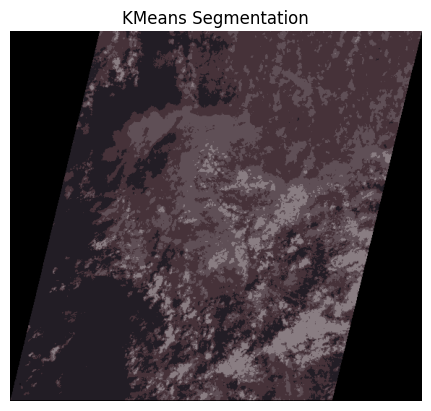

Class Distribution: {'class_0': 0.21984649122807018, 'class_1': 0.05904947916666667, 'class_2': 0.3072094298245614, 'class_3': 0.22101493969298244, 'class_4': 0.19287966008771928}


In [7]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('/content/R2F05OCT2022059484009400059SSANSTUC00GTDD.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Reshape image to (num_pixels, 3)
pixels = img_rgb.reshape((-1, 3))

# Apply KMeans (set number of clusters/classes)
k = 5
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(pixels)

# Calculate distribution
unique, counts = np.unique(labels, return_counts=True)
total_pixels = pixels.shape[0]
distribution = {f'class_{i}': int(c) / total_pixels for i, c in zip(unique, counts)}

# Visualize segmentation
segmented_img = kmeans.cluster_centers_[labels].reshape(img.shape).astype(np.uint8)

# Show segmented result
plt.imshow(segmented_img)
plt.title("KMeans Segmentation")
plt.axis('off')
plt.show()

# Print class distribution
print("Class Distribution:", distribution)


In [2]:
{

 'class_3': 0.31066680372807015,
 'class_2': 0.36043722587719296,
  'class_0':  0.22117598684210527,
 'class_1': 0.10771998355263158,
}



{'class_3': 0.31066680372807015,
 'class_2': 0.36043722587719296,
 'class_0': 0.22117598684210527,
 'class_1': 0.10771998355263158}

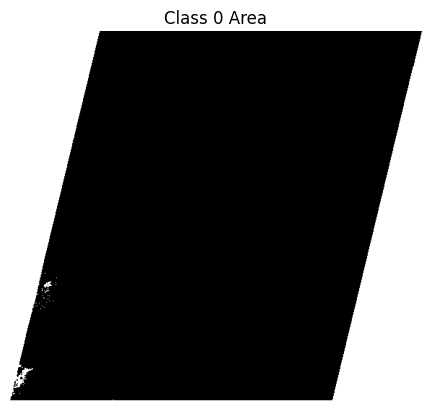

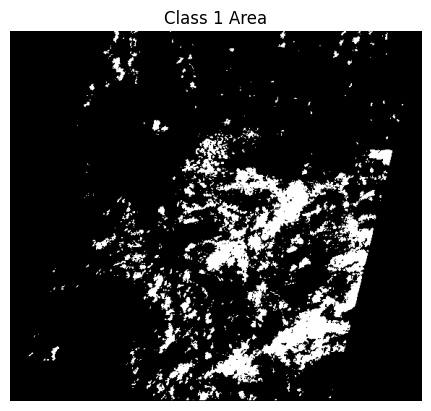

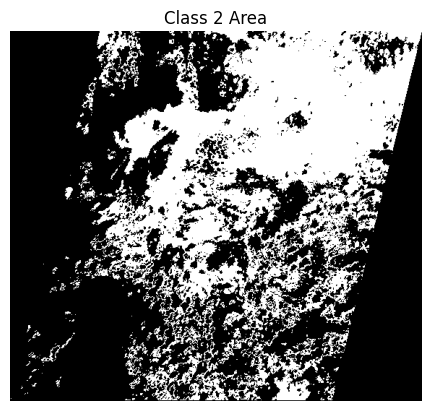

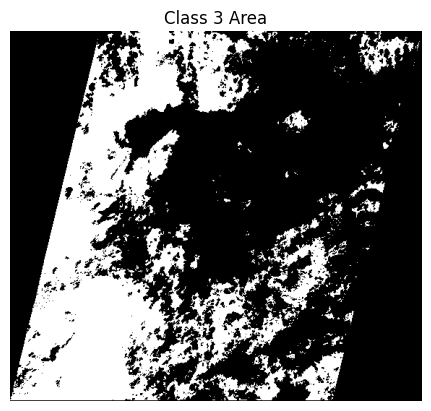

In [3]:
import matplotlib.pyplot as plt

h, w, _ = img.shape
label_image = labels.reshape(h, w)

# Plot each class mask
for i in range(k):
    mask = (label_image == i).astype(np.uint8) * 255
    plt.imshow(mask, cmap='gray')
    plt.title(f'Class {i} Area')
    plt.axis('off')
    plt.show()


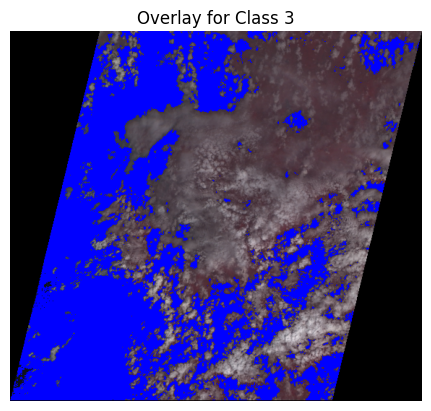

In [4]:
overlay = img.copy()
overlay[label_image == i] = [255, 0, 0]  # Highlight cluster i in red
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f'Overlay for Class {i}')
plt.axis('off')
plt.show()


In [5]:
for i in range(k):
    cluster_pixels = pixels[labels == i]
    mean_color = cluster_pixels.mean(axis=0)
    print(f'Class {i} mean RGB:', mean_color)


Class 0 mean RGB: [0.16742579 0.12209518 0.18936295]
Class 1 mean RGB: [124.22686643 110.93453574 116.917613  ]
Class 2 mean RGB: [80.86861869 62.72050575 69.94659188]
Class 3 mean RGB: [42.21232008 32.57023107 40.21666575]
